# 1. 介入分布からの画像生成とその性能向上のためのハイパラ探索

## 1.1 データセットとパイプラインの準備

In [1]:
import os

os.chdir("/home/hashikami/projects/Diff")

In [2]:
from pathlib import Path
from pipeline.utils import dict2namespace
import yaml


config_path = Path("config/config_all.yaml")
with open(config_path, "r") as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
config = dict2namespace(config_raw)

In [3]:
%load_ext autoreload
%autoreload 2

from pipeline.causal_pipeline import CausalPipeline

pipeline = CausalPipeline(config)

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Morpho-MNISTデータのロード

from dataset.morphomnist import load_morphomnist_like

dataset_dir = "/home/hashikami/datadrive/MorphoMNIST"
_, _, metrics_df = load_morphomnist_like(dataset_dir)
metrics = metrics_df.to_numpy()
metrics = metrics[:, [1, 0]] # thickness, intensityの順序が逆のため入れ替える

## 1.2 NOTEARSとCAREFLの適用

In [5]:
# notearsの適用

from pipeline.causal_pipeline import CausalPipeline


pipeline = CausalPipeline(config)
B_est = pipeline.run_causal_discovery(metrics)
B_est

Running causal discovery for meta-data


array([[0, 0],
       [1, 0]], dtype=int32)

In [6]:
# careflの訓練

config.carefl.scale_shift_base = True
config.carefl_training.epochs = 30
carefl = pipeline.train_meta_causal_model(metrics, B_est)

Training meta-causal model


100%|██████████| 30/30 [02:12<00:00,  4.41s/it]


In [7]:
# causal_pipeline.pyを修正してリロードした場合
# careflを再学習するのは手間のためpipeline.careflを編集前に学習したもので初期化

pipeline.carefl = carefl

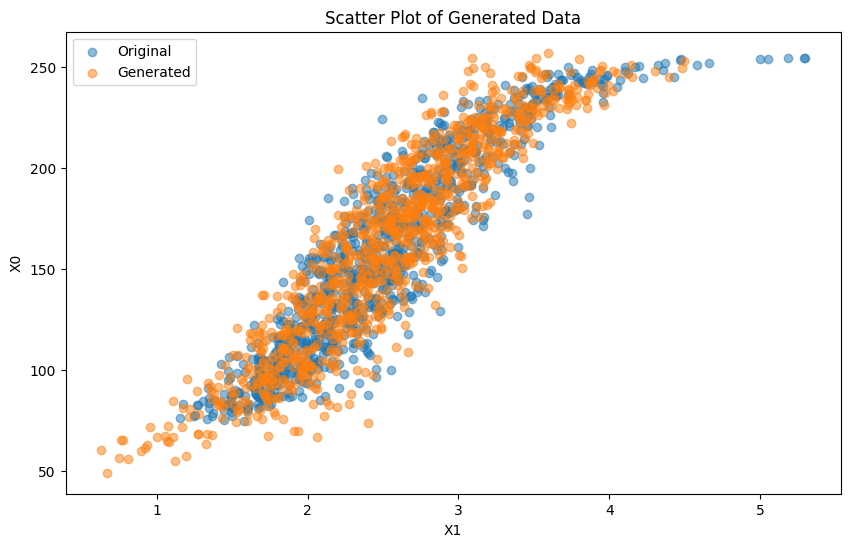

In [8]:
# 生成性能の確認

import matplotlib.pyplot as plt
import numpy as np
import torch

x_idx = 1
y_idx = 0

n = 1000
indices = np.random.choice(len(metrics), n)
X = metrics[indices]
xs = carefl.flow.sample(n)
X_gen = xs[-1].detach().cpu().numpy()

plt.figure(figsize=(10, 6))
plt.scatter(X[:, x_idx], X[:, y_idx], alpha=0.5, label='Original')
plt.scatter(X_gen[:, x_idx], X_gen[:, y_idx], alpha=0.5, label='Generated')
plt.xlabel(f'X{x_idx}')
plt.ylabel(f'X{y_idx}')
plt.title('Scatter Plot of Generated Data')
plt.legend()
plt.show()

やはりルートノードのスケールに合わせるためにscale_base_shift=Trueとすることでうまく学習できたようだ。

## 1.3 介入分布からの画像生成

In [9]:
## UNetのロード
import torch
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint, load_json
import torch.optim  as optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-07-17_16/config_20250717.json"
config = load_json(file_path)
epochs = config['epochs']
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


# checkpointの読み込み
checkpoint_path = "/home/hashikami/checkpoint/checkpoint_2025-07-17_18.pth"
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename=checkpoint_path)


In [49]:
# 介入分布からの生成

int_idx = [1]
int_val = [2.5]

pipeline.denoise_model = denoise_model
imgs = pipeline.intervene_generate(int_idx, int_val, num_samples=1, w=0.5)

Intervening and generating samples


sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 50.20it/s]


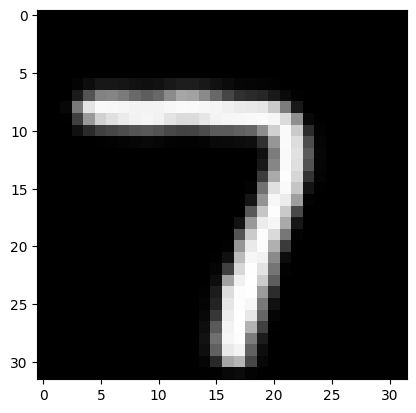

In [50]:
import matplotlib.pyplot as plt

plt.imshow(imgs[-1][0].permute(1, 2, 0).detach().cpu().numpy(), cmap='gray')

## 2 観測画像の反事実的画像編集とその性能向上に向けたハイパラ探索

## 2.1 観測画像の準備

In [10]:
import os

os.chdir("/home/hashikami/projects/Diff")

In [27]:
# 5の画像を使う場合

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
images_obs = torch.load("./resources/image5_size32_scale255.pt", map_location=device).unsqueeze(0) / 255.0
x_obs = torch.load("./resources/metrics_image5.pt", map_location=device)

In [ ]:
# 9の画像を使う場合

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
images_obs = torch.load("./resources/image9_size32_scale255.pt", map_location=device).unsqueeze(0) / 255.0
x_obs = torch.load("./resources/metrics_image9.pt", map_location=device)

In [28]:
print(x_obs)

tensor([[166.7316,   1.8436]], device='cuda:0')


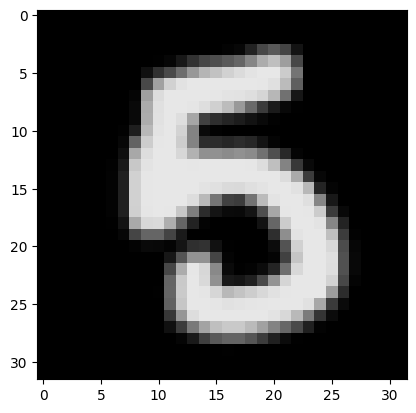

In [29]:
import matplotlib.pyplot as plt

plt.imshow((images_obs.squeeze(0).permute(1, 2, 0) * 255.0).detach().cpu().numpy(), cmap='gray', vmin=0, vmax=255)

## 2.2 観測画像の反事実的編集

### 試しに一回編集

In [17]:
pipeline.denoise_model = denoise_model

In [ ]:
cf_idx = [0]
cf_val = [100.0]

imgs = pipeline.counterfactual_editing(images_obs, x_obs, cf_idx, cf_val, w=0.1)

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 50.73it/s]


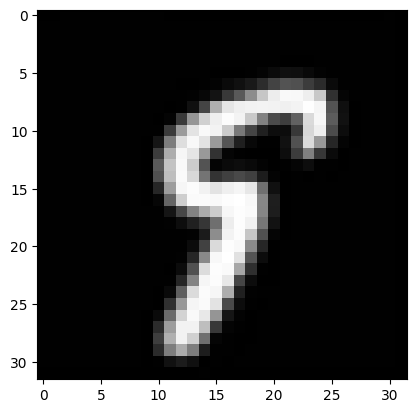

In [40]:
import matplotlib.pyplot as plt

plt.imshow((imgs[-1][0] * 255.0).permute(1, 2, 0).detach().cpu().numpy(), cmap='gray')

## 複数の反事実ケースで編集

In [ ]:
# 反事実推論のための介入値の設定
w = 0.8
cf_dict = {
    'intensity': [80.0, 100.0, 150.0, 200.0, 250.0],
    'thickness': [1.5, 2.0, 2.5, 3.0, 3.5]
}

# 反事実推論のための画像の保存
cf_intensity_images = []
cf_thickness_images = []
for meta, cf_vals in cf_dict.items():
    if meta == 'intensity':
        cf_idx = [0]
    elif meta == 'thickness':
        cf_idx = [1]
    else:
        raise ValueError(f"Invalid meta: {meta}")
    
    for cf_val in cf_vals:
        imgs = pipeline.counterfactual_editing(images_obs, x_obs, cf_idx, cf_val, w=w)
        if meta == 'intensity':
            cf_intensity_images.append(imgs[-1][0].permute(1, 2, 0).detach().cpu().numpy())
        elif meta == 'thickness':
            cf_thickness_images.append(imgs[-1][0].permute(1, 2, 0).detach().cpu().numpy())
        else:
            raise ValueError(f"Invalid meta: {meta}")
        

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 51.52it/s]


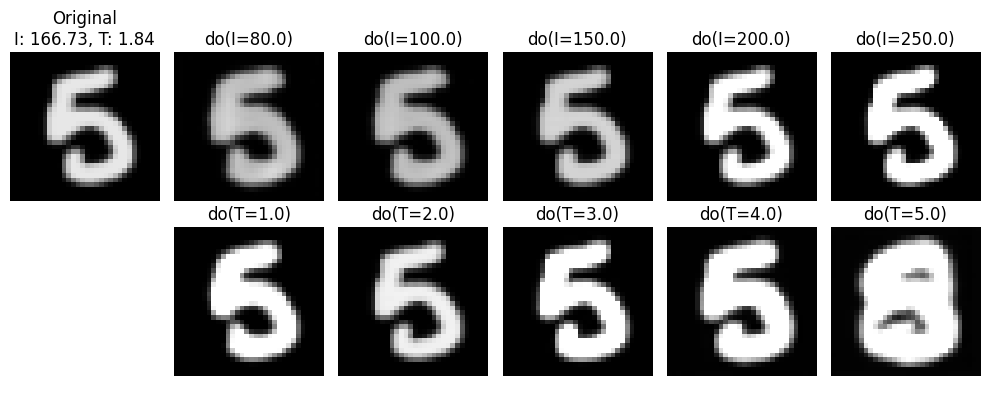

In [21]:
# 元の画像と反事実的編集結果画像の可視化

fig, axes = plt.subplots(2, 6, figsize=(10, 4))

axes[0, 0].imshow((images_obs[0].permute(1, 2, 0) * 255.0).detach().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title(f"Original\nI: {x_obs[0, 0]:.2f}, T: {x_obs[0, 1]:.2f}")

for meta, cf_vals in cf_dict.items():
    if meta == 'intensity':
        for i, cf_val in enumerate(cf_vals):
            axes[0, i+1].imshow(cf_intensity_images[i] * 255.0, cmap='gray', vmin=0, vmax=255)
            axes[0, i+1].set_title(f"do(I={cf_val})")
    if meta == 'thickness':
        for i, cf_val in enumerate(cf_vals):
            axes[1, i+1].imshow(cf_thickness_images[i] * 255.0, cmap='gray', vmin=0, vmax=255)
            axes[1, i+1].set_title(f"do(T={cf_val})")

# 全ての軸の表示を消す
for row in axes:
    for ax in row:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
# thicknessに介入した場合の反事実的メタ情報値を確認

cf_idx = [1]
for cf_val in cf_dict['thickness']:
    x_cf = pipeline.carefl.predict_counterfactual(x_obs, cf_idx, cf_val)
    print(x_cf)

tensor([[60.3710,  1.5000]], device='cuda:0', grad_fn=<CopySlices>)
tensor([[69.1524,  2.0000]], device='cuda:0', grad_fn=<CopySlices>)
tensor([[93.3968,  2.5000]], device='cuda:0', grad_fn=<CopySlices>)
tensor([[138.7110,   3.0000]], device='cuda:0', grad_fn=<CopySlices>)
tensor([[188.5981,   3.5000]], device='cuda:0', grad_fn=<CopySlices>)
